In [2]:
import csv
import numpy as np
import matplotlib.pyplot as plt

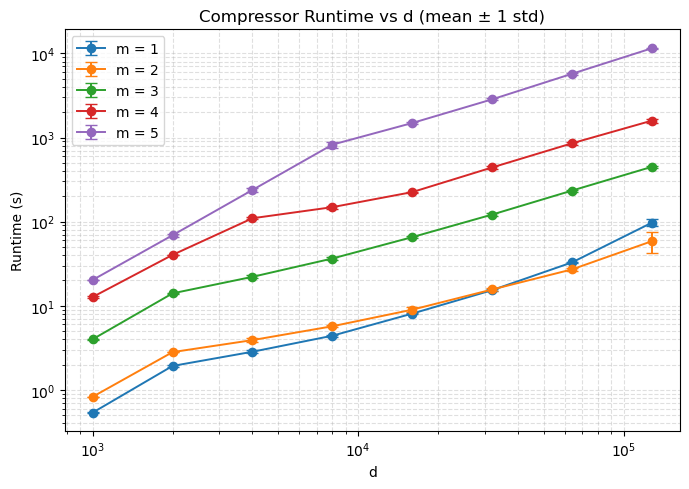

In [7]:
# Load CSV
records = []
with open("time_list.csv", "r") as f:
    reader = csv.DictReader(f)
    for row in reader:
        m = int(row["m"])
        d = int(row["d"])
        t = float(row["runtime"])
        records.append((m, d, t))

records = np.array(records, dtype=[("m", int), ("d", int), ("t", float)])

m_list = np.unique(records["m"])
d_list = np.unique(records["d"])

# Compute mean and std for each (m, d)
stats = {}
for m in m_list:
    for d in d_list:
        ts = records[(records["m"] == m) & (records["d"] == d)]["t"]
        if len(ts) > 0:
            stats[(m, d)] = (np.mean(ts), np.std(ts))
        else:
            stats[(m, d)] = (np.nan, np.nan)

# Plot
plt.figure(figsize=(7, 5))

for m in m_list:
    means = []
    stds = []
    for d in d_list:
        mean, std = stats[(m, d)]
        means.append(mean)
        stds.append(std)
    plt.errorbar(
        d_list,
        means,
        yerr=stds,
        marker="o",
        capsize=4,
        label=f"m = {m}",
        linewidth=1.4,
    )

plt.xlabel("d")
plt.ylabel("Runtime (s)")
plt.title("Compressor Runtime vs d (mean ± 1 std)")
plt.xscale("log")
plt.yscale("log")
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
np.log(32000)**2*20

2152.186385970122